### Step 1: Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import normalize
from tensorflow.keras import layers

### Step 2: Import data and normalize

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [5]:
x_train = normalize(x_train,axis=1)
x_test = normalize(x_test,axis=1)

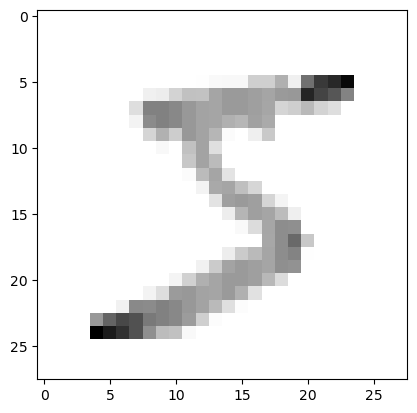

In [6]:
plt.imshow(x_train[0], cmap=plt.cm.binary)

### Step 3: Make a Neural Network and Train it

In [7]:
class NeuralNetwork(tf.keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.flatten = layers.Flatten()
        self.fn1 = layers.Dense(128, activation=tf.nn.relu)
        self.fn2 = layers.Dense(128, activation=tf.nn.relu)
        self.fn3 = layers.Dense(10, activation=tf.nn.softmax)

    def call(self, x):
        x = self.flatten(x)
        x = self.fn1(x)
        x = self.fn2(x)
        x = self.fn3(x)
        return x       

    # # 返回配置给 load_model 使用
    # def get_config(self):
    #     config = super().get_config()
    #     # 可以在这里加入你想保存的额外参数
    #     return config

    # @classmethod
    # def from_config(cls, config):
    #     return cls(**config)

In [8]:
model = NeuralNetwork()

In [9]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [10]:
history = model.fit(x_train, y_train, epochs=3, batch_size=32)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9235 - loss: 0.2668
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9668 - loss: 0.1073
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9767 - loss: 0.0731


### Step 4: Check Model Accuracy and Loss

In [11]:
val_loss, val_acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.9696 - loss: 0.1022


In [12]:
print("loss-> ", round(val_loss, 3),"\nacc-> ",round(val_acc, 3))

loss->  0.102 
acc->  0.97


### Step 5: Prediction Using Model 

In [13]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step


In [14]:
def draw(i):
    print('label -> ',y_test[i])
    print('prediction -> ',np.argmax(predictions[i]))
    plt.imshow(x_test[i], cmap=plt.cm.binary)

label ->  5
prediction ->  5


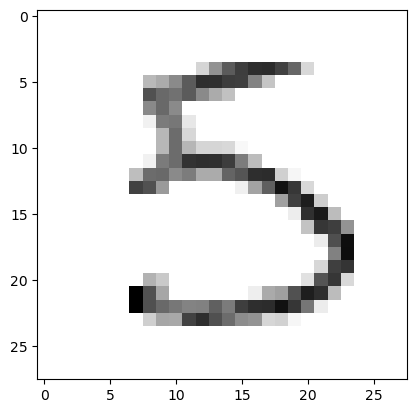

In [15]:
draw(15)

### Step 6: Saving and Loading Model 

In [16]:
model.save_weights('./data/epic_num_reader.weights.h5')

In [17]:
new_model = NeuralNetwork()

In [24]:
new_model.build(input_shape=(28, 28))

In [25]:
new_model.load_weights('./data/epic_num_reader.weights.h5')

In [26]:
predictions = new_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step


label ->  4
prediction ->  4


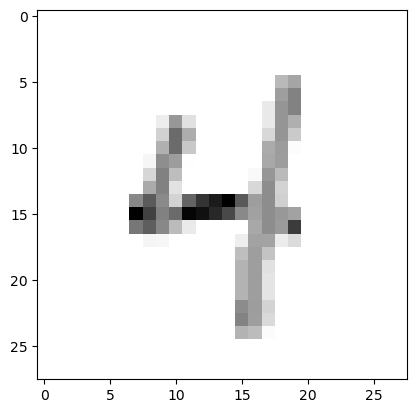

In [30]:
draw(19)